In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
kentvejrupmadsen_letter_images_dataset_path = kagglehub.dataset_download('kentvejrupmadsen/letter-images-dataset')

print('Data source import complete.')


100%|██████████| 7.18G/7.18G [01:33<00:00, 82.6MB/s]

Extracting files...


Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## 1. Load and Preprocess the Data

In [3]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

data = []     #store loaded images
labels = []   #store class label(folder name)

dataset = os.path.join(kentvejrupmadsen_letter_images_dataset_path, 'dataset')

folders = sorted(os.listdir(dataset))
#list everything inside the directory and keep it in sorted format.

for folder in folders:
    folder_path = os.path.join(dataset, folder)

    if not os.path.isdir(folder_path):
        continue

    #builds the full path safely and if is not a folder, skip.

    print("Loading:", folder)

    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        try:
            img = Image.open(img_path).convert("L")
            #opens image file and converts to grayscale(L)
        except FileNotFoundError:
            print(f"Skipping missing file: {img_path}")
            continue
        except Exception as e:
            print(f"Skipping unreadable file {img_path} due to error: {e}")
            continue

        # Skip unreadable images
        if img is None:
            print("Skipping unreadable file:", img_path)
            continue
        IMAGE_SIZE = (64, 64) # Reduced image size to save memory
        img = img.resize(IMAGE_SIZE)

        data.append(img)
        labels.append(folder)

Loading: 0
Loading: 1
Loading: 2
Loading: 3
Loading: 4
Loading: 5
Loading: 6
Loading: 7
Loading: 8
Loading: 9
Loading: A
Loading: B
Loading: C
Loading: D
Loading: E
Loading: F
Loading: G
Loading: H
Loading: I
Loading: J
Loading: K
Loading: L
Loading: M
Loading: N
Loading: O
Loading: P
Loading: Q
Loading: R
Loading: S
Loading: T
Loading: U
Loading: V
Loading: W
Loading: X
Loading: Y
Loading: Z
Loading: ampersands
Loading: apostrophe
Loading: arrows
Loading: asterisks
Loading: at
Loading: backslashs
Loading: barcodes
Loading: carets
Loading: colons
Loading: commas
Loading: copyrights
Loading: curly.left
Loading: curly.right
Loading: degrees
Loading: dots
Loading: equals
Loading: exclamation
Loading: headphones
Loading: hyphens
Loading: keyboards
Loading: networks
Loading: nfcs
Loading: parentheses.left
Loading: parentheses.right
Loading: percentages
Loading: plus
Loading: qrs
Loading: questions
Loading: quotations
Loading: screens
Loading: semicolons
Loading: slashs
Loading: squares.left

This code block is responsible for loading all your image data from the dataset, converting them to a standard format, and preparing them for use in a machine learning model. Here's a breakdown:

First, it sets up empty lists called data (to store the images) and labels (to store what each image represents, like 'A' or 'B'). It then figures out where your image dataset is located on your computer.

Next, it goes through each folder in your dataset. Each folder represents a different class (like the letter 'A' or the number '0'). Inside each folder, it looks for all the image files. For every image it finds, it tries to open it and convert it into a grayscale image (black and white). If it can't open an image (maybe it's missing or corrupted), it just skips that image and tells you about it.

After opening, it resizes every image to a standard size of 64x64 pixels, which is important for neural networks. Finally, it adds the resized image to the data list and the name of the folder (which is its label) to the labels list. This process continues until all images from all folders are loaded.

In [4]:
import numpy as np
data = np.array(data)
labels = np.array(labels)


print("Loaded images:", data.shape)
print("Loaded labels:", labels.shape)

Loaded images: (64800, 64, 64)
Loaded labels: (64800,)


data becomes a NumPy array of image pixel values and labels becomes a NumPy array of labels cause Neural networks cannot work with Python lists

- ### Normalize the data

In [5]:
data = data.astype("float32") / 255

It first converts the image pixel values to the float32 data type, which is efficient and standard for neural networks, and then scales these values from their original range (typically 0-255) down to a new range between 0.0 and 1.0

- ### Flatten the images

In [6]:
data = data.reshape(data.shape[0], -1)


This line of code, `data = data.reshape(data.shape[0], -1)`, is used to flatten your image data.

- `data.shape[0]`: This retains the number of samples (images) in your dataset.

- `-1`: This is a placeholder that tells NumPy to calculate the remaining dimension. In this case, it flattens each 64x64 image into a single vector of 4096 (64 * 64) pixels.

This flattening is necessary because a Multilayer Perceptron (MLP) expects a 1D input vector for each sample, rather than a 2D (or 3D for color images) array. This operation prepares the image data for input into the first dense layer of your MLP model.

- ### Encode Labels

In [7]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

encoder = LabelEncoder()
y = encoder.fit_transform(labels)
y = to_categorical(y)

#converts each label into integer, which later gets converted into one-hot vectors for neural network to learn.

print("Number of classes:", y.shape[1])

Number of classes: 82


This code segment is crucial for preparing your categorical labels (like 'A', 'B', 'C', '0', '1', etc.) for use with a neural network, which requires numerical input.

-   **`from sklearn.preprocessing import LabelEncoder`**: Imports `LabelEncoder` from scikit-learn, which is used to convert categorical text labels into numerical labels.
-   **`from tensorflow.keras.utils import to_categorical`**: Imports `to_categorical` from Keras, a utility function to convert integer labels into one-hot encoded vectors.

### Explanation of the steps:

1.  **`encoder = LabelEncoder()`**: An instance of `LabelEncoder` is created. This object will learn all unique labels in your dataset and assign an integer to each.

2.  **`y = encoder.fit_transform(labels)`**: The `fit_transform` method does two things:
    -   `fit`: It inspects the `labels` array to find all unique categorical values (e.g., 'A', 'B', '0', 'unidentifiable').
    -   `transform`: It then replaces each categorical label with its corresponding unique integer. For example, 'A' might become 0, 'B' might become 1, and so on.

3.  **`y = to_categorical(y)`**: Neural networks often perform better when output labels are represented as one-hot encoded vectors, especially for multi-class classification problems. `to_categorical` converts the integer-encoded labels into a binary matrix, where each row represents a sample, and each column corresponds to a class. A '1' in a column indicates that the sample belongs to that class, and '0' otherwise.
    -   For instance, if you have 82 classes and a label was encoded as `5`, `to_categorical` would convert it to a vector like `[0, 0, 0, 0, 0, 1, 0, ..., 0]` (a vector of length 82 with a '1' at the 5th index).

-   **`print("Number of classes:", y.shape[1])`**: This line prints the total number of unique classes identified, which corresponds to the number of columns in the one-hot encoded `y` array.

- ### Train-Test Split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data, y, test_size=0.2, random_state=42
)
#divides your data into training and testing sets so the model learns from one part and is evaluated on unseen samples.
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (51840, 4096)
Test shape: (12960, 4096)


This code snippet uses the `train_test_split` function from the `sklearn.model_selection` module to divide your dataset into training and testing sets.

-   **`X_train, X_test, y_train, y_test`**: These are the four outputs of the function:
    -   `X_train`: The features (image data) for training the model.
    -   `X_test`: The features (image data) for testing the model's performance on unseen data.
    -   `y_train`: The corresponding labels for the training set.
    -   `y_test`: The corresponding labels for the testing set.

-   **`data, y`**: These are the input features (`data`) and corresponding labels (`y`) that are being split.

-   **`test_size=0.2`**: This parameter specifies that 20% of the data should be used for the test set, and the remaining 80% will be used for the training set.

-   **`random_state=42`**: This parameter ensures reproducibility. If you use the same `random_state` value, the split will be the same every time you run the code. This is important for consistent experimentation.

-   **`print("Train shape:", X_train.shape)`** and **`print("Test shape:", X_test.shape)`**: These lines print the dimensions (number of samples and features) of the resulting training and testing sets, confirming how the data has been divided.

## 2. Build and Compile the MLP model

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Create the model
model = Sequential()
# Add input layer and first hidden layer with corrected input_shape
model.add(Dense(512, input_shape=(4096,), activation='relu'))
# Add second hidden layer
model.add(Dense(256, activation='relu'))
# Add output layer with corrected number of classes
model.add(Dense(82, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy',
metrics=['accuracy'])
# Summarize the model
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 82)             │        21,074 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,250,066 (8.58 MB)

 Trainable params: 2,250,066 (8.58 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Train the Model for 10 epochs

In [15]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=128,
validation_split=0.2)


    #trains the MLP using a chosen optimizer and batch size

Epoch 1/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.0563 - loss: 3.9711 - val_accuracy: 0.0611 - val_loss: 3.9124
Epoch 2/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0616 - loss: 3.9106 - val_accuracy: 0.0611 - val_loss: 3.8984
Epoch 3/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0618 - loss: 3.8961 - val_accuracy: 0.0612 - val_loss: 3.8868
Epoch 4/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0624 - loss: 3.8805 - val_accuracy: 0.0612 - val_loss: 3.8723
Epoch 5/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0625 - loss: 3.8711 - val_accuracy: 0.0611 - val_loss: 3.8682
Epoch 6/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0626 - loss: 3.8614 - val_accuracy: 0.0614 - val_loss: 3.8595
Epoch 7/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0633 - loss: 3.8536 - val_accuracy: 0.0616 - val_loss: 3.8733
Epoch 8/10
324/324 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.0641 - loss: 3.8448 - val_accuracy: 0.

## 4. Evaluate the model

In [16]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.0660 - loss: 3.8473
Test accuracy: 0.0659722238779068


## 5. Save the Model

In [17]:
model.save('symbols_mlp_model.h5')

## 6. Load and Use the Model for Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step
Predicted class: [73]


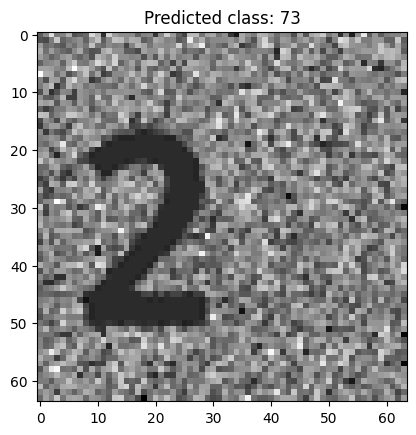

In [27]:
import tensorflow as tf
# Load the model
loaded_model = tf.keras.models.load_model('symbols_mlp_model.h5')
# Predict on a test sample
import numpy as np
# Pick a test sample
input = 20
sample = X_test[input].reshape(1, -1)
# Predict the class
prediction = loaded_model.predict(sample)
predicted_class = np.argmax(prediction, axis=1)
print(f"Predicted class: {predicted_class}")
# Display the test sample
plt.imshow(X_test[input].reshape(64, 64), cmap='gray')
plt.title(f"Predicted class: {predicted_class[0]}")
plt.show()